In [1]:
# Open count stores and run Scarf analyses.
import scarf
# Select explicit fields and display options for plots.
from scarf.plotting import CellField, FeatureRef

# Keep routine logs and progress bars out of the results.
scarf.configure_output(level="WARNING", progress=False)

# Download the prepared example store.
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "swanson_7K_pbmc_teaseq",
    destination="scarf_datasets",
    zarr=True,
)
# Open the count store for this analysis.
ds = scarf.DataStore(f"{dataset}/data.zarr", default_assay="RNA", nthreads=4)
# Inspect the opened store's cells and features.
ds

Downloading bucket files: 487959744 / 487959744 complete

Downloading bytes: 487959744 / 487959744 complete

DataStore has 6194 (7069) cells with 3 assays: ADT ATAC RNA
   Cell metadata:
            'I', 'ids', 'names', 'ADT_UMAP1', 'ADT_UMAP2', 
            'ADT_leiden_cluster', 'ADT_nCounts', 'ADT_nFeatures', 'ATAC_UMAP1', 'ATAC_UMAP2', 
            'ATAC_leiden_cluster', 'ATAC_nCounts', 'ATAC_nFeatures', 'DoubletEnrichment', 'DoubletScore', 
            'RNA+ATAC+ADT_UMAP1', 'RNA+ATAC+ADT_UMAP2', 'RNA+ATAC+ADT_leiden_cluster', 'RNA+ATAC+ADT_wnn_UMAP1', 'RNA+ATAC+ADT_wnn_UMAP2', 
            'RNA+ATAC+ADT_wnn_leiden_cluster', 'RNA_UMAP1', 'RNA_UMAP2', 'RNA_leiden_cluster', 'RNA_nCounts', 
            'RNA_nFeatures', 'TSSEnrichment', 'altius_count', 'altius_frac', 'barcodes', 
            'batch_id', 'cell_name', 'chip_id', 'gene_bodies_count', 'gene_bodies_frac', 
            'nCount_ADT', 'nCount_ATAC', 'nCount_RNA', 'nFeature_ADT', 'nFeature_ATAC', 
            'nFeature_RNA', 'n_duplicate', 'n_fragments', 'n_mito', 'n_unique', 
            'orig.ident', 'original_barcodes', 'pbmc_sample

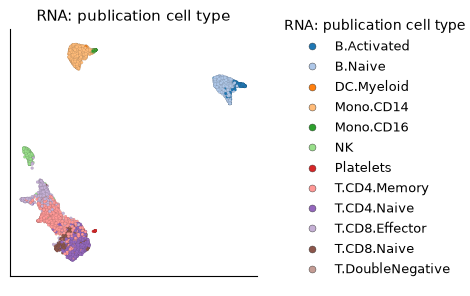

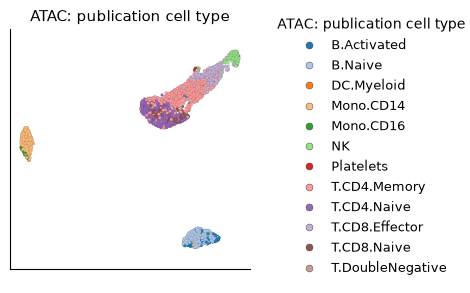

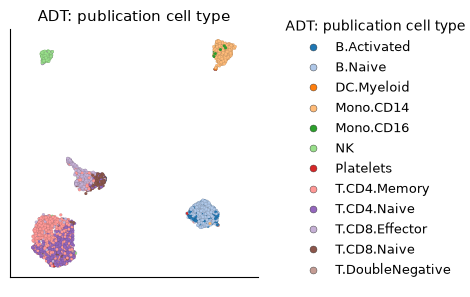

In [2]:
# Inspect the RNA, ATAC, and protein views in turn.
for assay in ("RNA", "ATAC", "ADT"):
    # Select the saved layout for this assay; require exactly one match.
    [layout] = ds.list_artifacts(
        from_assay=assay,
        kind="embedding",
        operation="run_umap",
        complete_only=True,
    )
    # Name the modality on its UMAP and color cells by the publication labels.
    ds.plots.embedding(
        layout=layout,
        color_by=CellField("tea_cell_type", label=f"{assay}: publication cell type"),
    )

In [3]:
# Select the saved WNN graph; require exactly one match.
[wnn_graph] = ds.list_artifacts(
    scope="datastore",
    kind="integrated_graph",
    operation="integrate_assays",
    parameters={"method": "wnn"},
    complete_only=True,
)
# Select the saved WNN layout; require exactly one match.
[wnn_layout] = ds.list_artifacts(
    scope="datastore",
    kind="embedding",
    operation="run_umap",
    inputs={"graph": wnn_graph},
    complete_only=True,
)
# Inspect the selected WNN graph and its matching layout.
{"WNN graph": wnn_graph, "WNN layout": wnn_layout}

{'WNN graph': ArtifactRef(datastore, kind='integrated_graph', artifact_id='c5fd947f637c...'),
 'WNN layout': ArtifactRef(datastore, kind='embedding', artifact_id='6b45054da417...')}

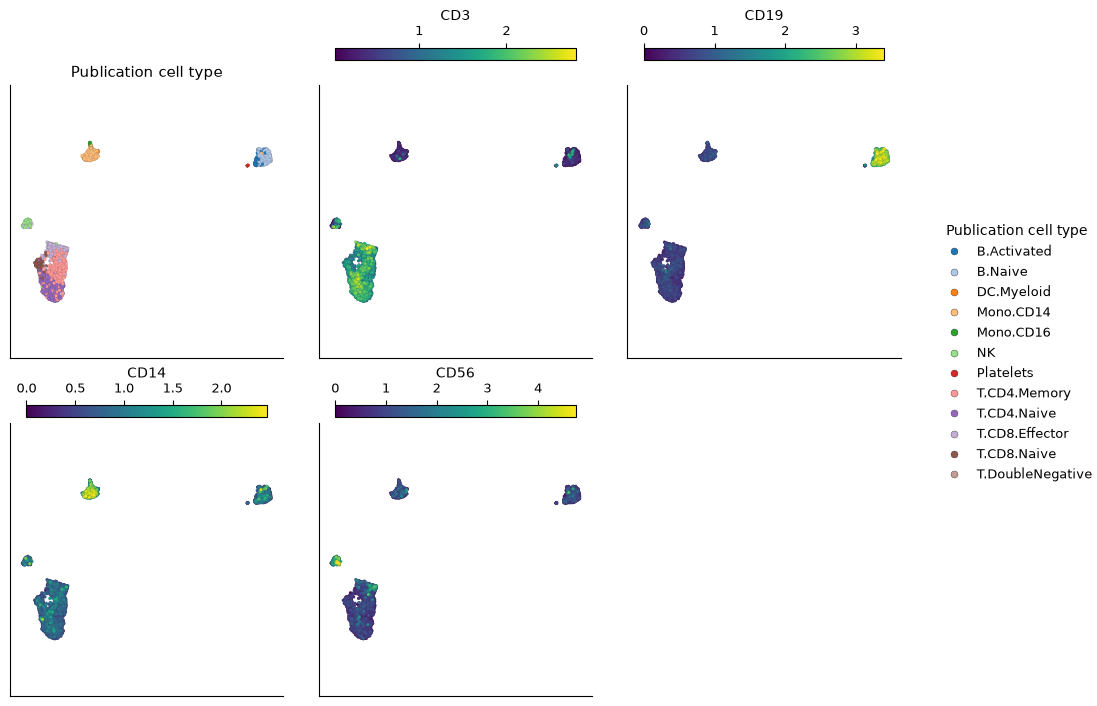

In [4]:
# Compare publication labels with four protein markers on the WNN map.
ds.plots.embedding(
    layout=wnn_layout,
    color_by=[
        CellField("tea_cell_type", label="Publication cell type"),
        FeatureRef("CD3", assay="ADT"),
        FeatureRef("CD19", assay="ADT"),
        FeatureRef("CD14", assay="ADT"),
        FeatureRef("CD56", assay="ADT"),
    ],
    n_columns=3,
    sort_values=True,
)

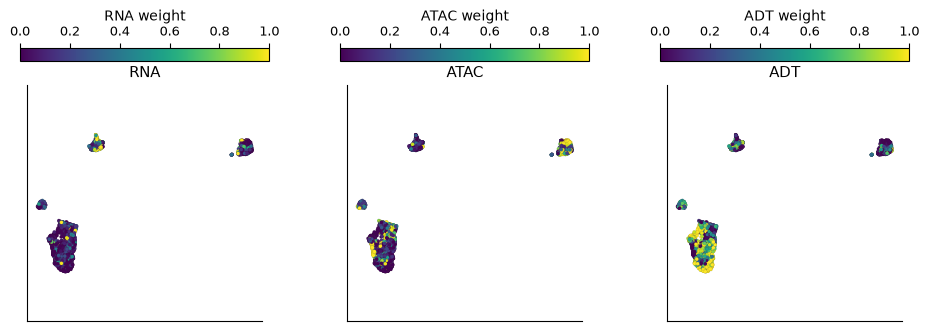

In [5]:
# Show how much each modality contributes across the joint map.
ds.plots.modality_weights(graph=wnn_graph, layout=wnn_layout)